In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
median_value = df["TotalCharges"].median()

df["TotalCharges"] = df["TotalCharges"].fillna(median_value)

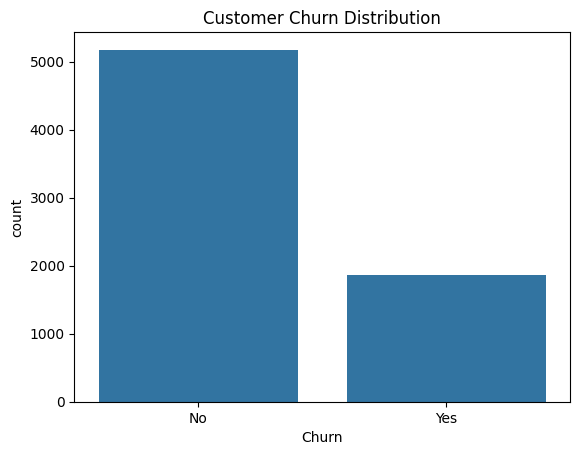

In [11]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

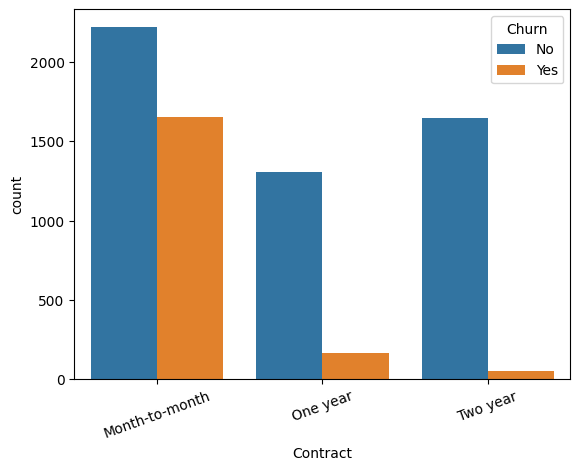

In [12]:
sns.countplot(

    x="Contract",

    hue="Churn",

    data=df

)

plt.xticks(rotation=20)

plt.show()

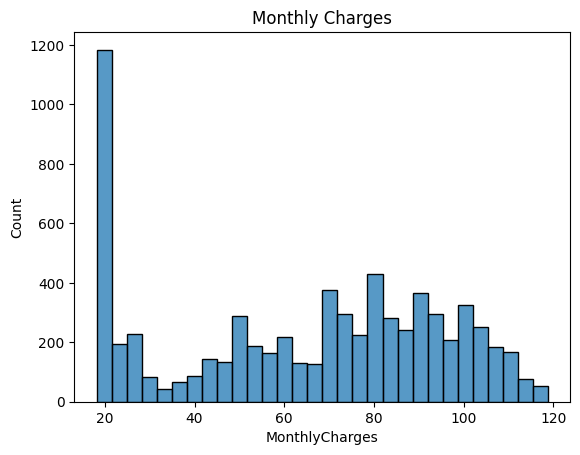

In [13]:
sns.histplot(

    df["MonthlyCharges"],

    bins=30

)

plt.title("Monthly Charges")

plt.show()

In [14]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


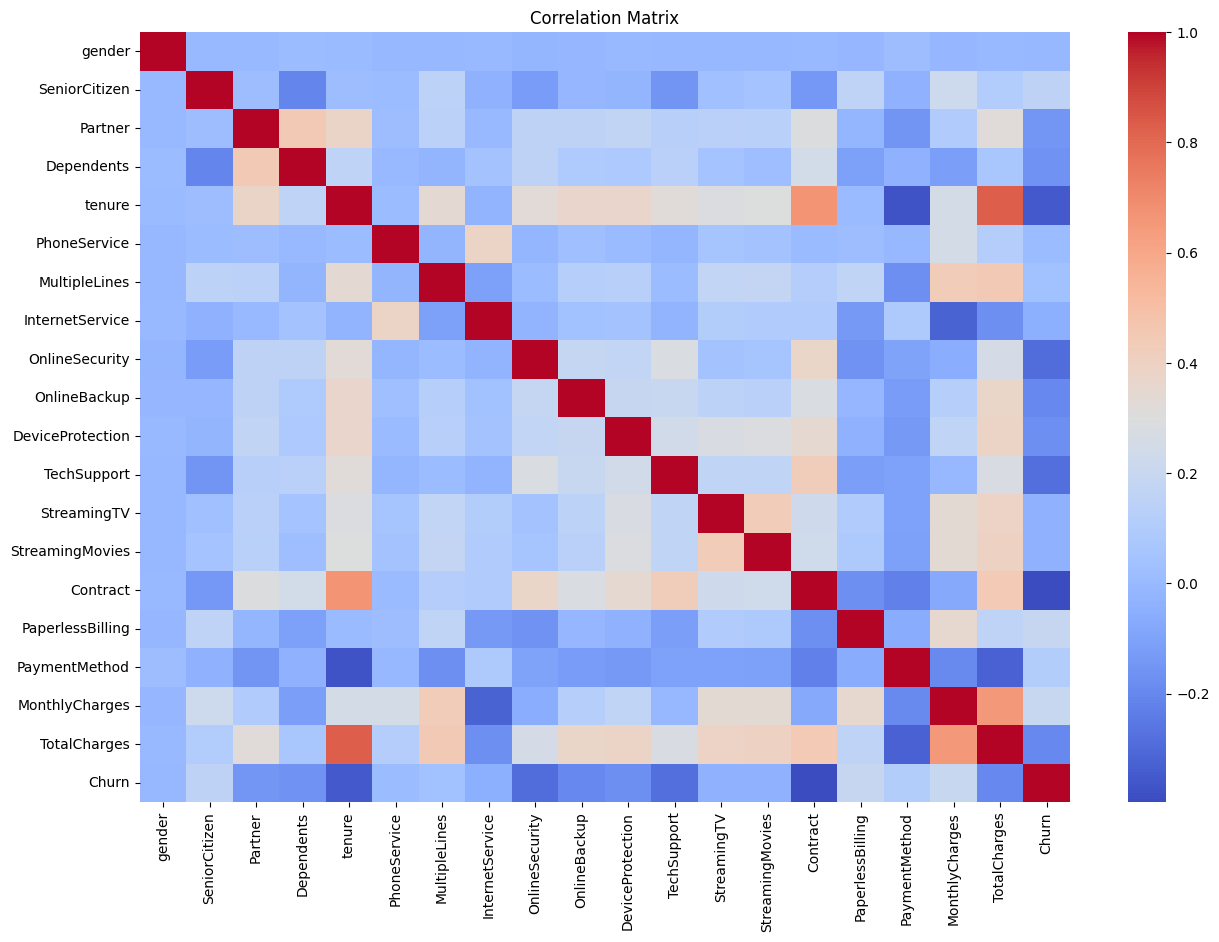

In [15]:
plt.figure(figsize=(15,10))

sns.heatmap(

    df.corr(),

    cmap='coolwarm'

)

plt.title("Correlation Matrix")

plt.show()

In [16]:
X = df.drop(

    "Churn",

    axis=1

)

y = df["Churn"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(5634, 19)
(1409, 19)


In [18]:
lr = LogisticRegression(

    max_iter=1000

)

lr.fit(

    X_train,

    y_train

)

pred_lr = lr.predict(X_test)

print(

    accuracy_score(

        y_test,

        pred_lr

    )

)

0.8161816891412349


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf.fit(

    X_train,

    y_train

)

pred_rf = rf.predict(X_test)

print(

    accuracy_score(

        y_test,

        pred_rf

    )

)

0.7955997161107168


In [20]:
xgb = XGBClassifier(

    n_estimators=100,

    learning_rate=0.1,

    max_depth=5,

    eval_metric='logloss'

)

xgb.fit(

    X_train,

    y_train

)

pred_xgb = xgb.predict(X_test)

print(

    accuracy_score(

        y_test,

        pred_xgb

    )

)

0.8062455642299503


In [21]:
print(

    classification_report(

        y_test,

        pred_xgb

    )

)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



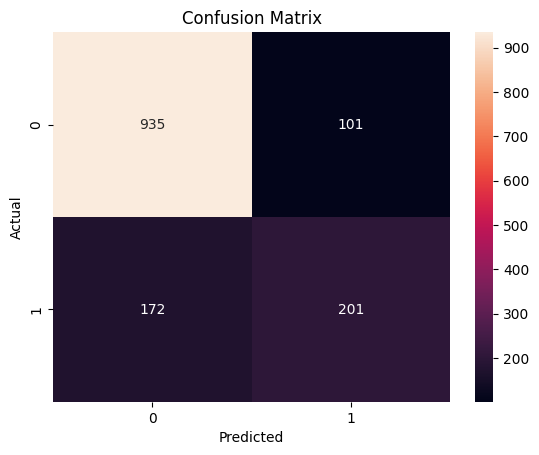

In [22]:
cm = confusion_matrix(

    y_test,

    pred_xgb

)

sns.heatmap(

    cm,

    annot=True,

    fmt='d'

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [23]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False

)

importance.head(10)

,Feature,Importance
18,TotalCharges,0.189992
17,MonthlyCharges,0.177867
4,tenure,0.157428
14,Contract,0.077357
16,PaymentMethod,0.050379
8,OnlineSecurity,0.047432
11,TechSupport,0.044190
0,gender,0.028117
9,OnlineBackup,0.027067
7,InternetService,0.026444


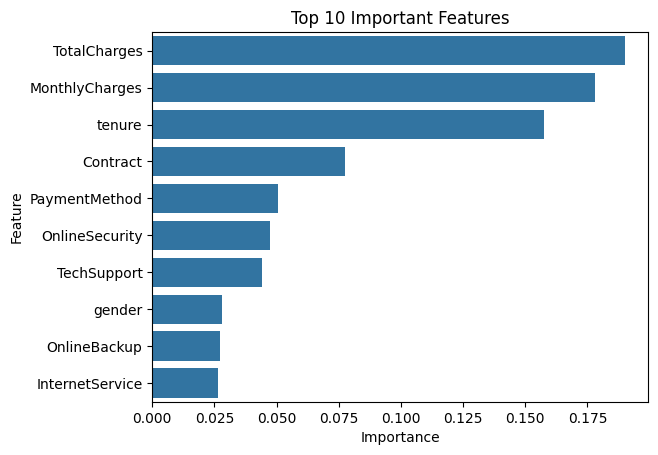

In [24]:
sns.barplot(

    x='Importance',

    y='Feature',

    data=importance.head(10)

)

plt.title(

    "Top 10 Important Features"

)

plt.show()